In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv") 
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [11]:
df = df.drop(columns=["Order_ID"], errors="ignore")

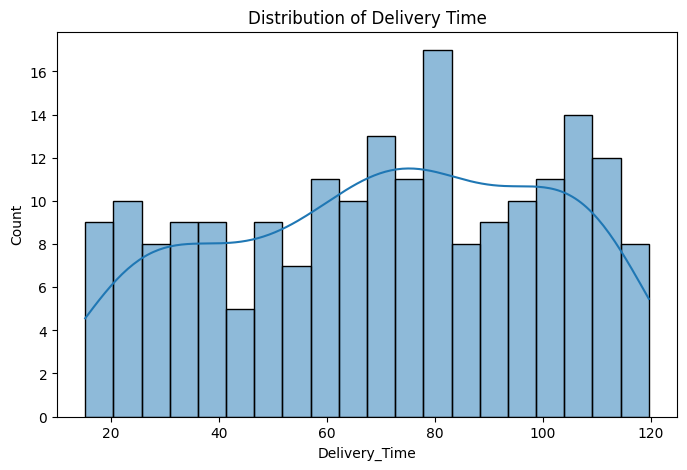

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Delivery_Time"], bins=20, kde=True)
plt.title("Distribution of Delivery Time")
plt.show()

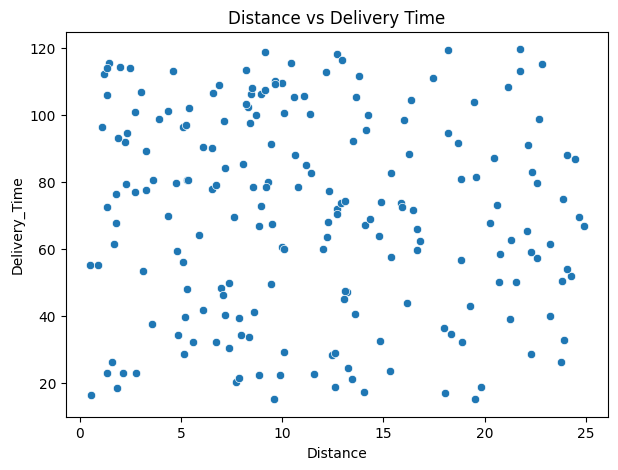

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Distance", y="Delivery_Time")
plt.title("Distance vs Delivery Time")
plt.show()

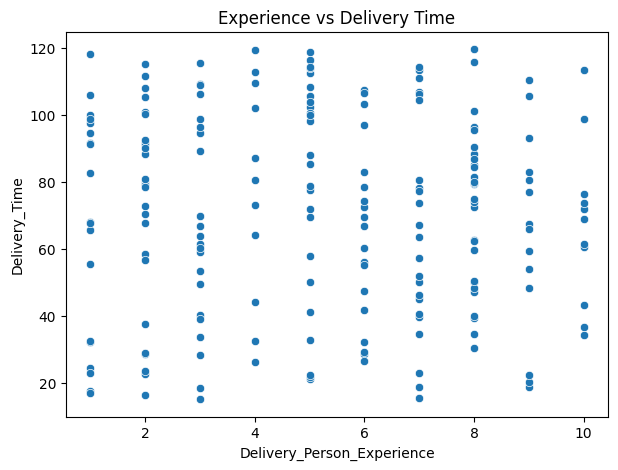

In [14]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Delivery_Person_Experience", y="Delivery_Time")
plt.title("Experience vs Delivery Time")
plt.show()

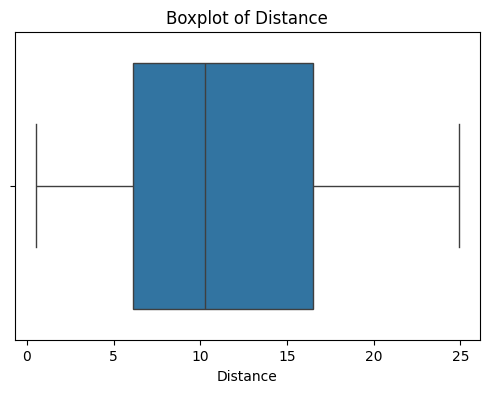

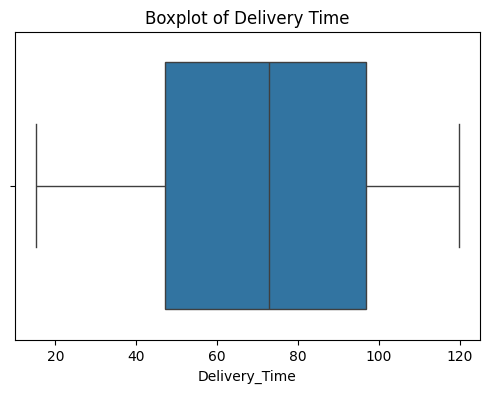

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Distance"])
plt.title("Boxplot of Distance")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Delivery_Time"])
plt.title("Boxplot of Delivery Time")
plt.show()

In [19]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return data[(data[column] >= lower) & (data[column] <= upper)]

df = remove_outliers_iqr(df, "Delivery_Time")

In [20]:
threshold = df["Delivery_Time"].median()
df["Delivery_Status"] = (df["Delivery_Time"] > threshold).astype(int)

In [21]:
X = df.drop(["Delivery_Time", "Delivery_Status"], axis=1)
y = df["Delivery_Status"]

In [22]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]

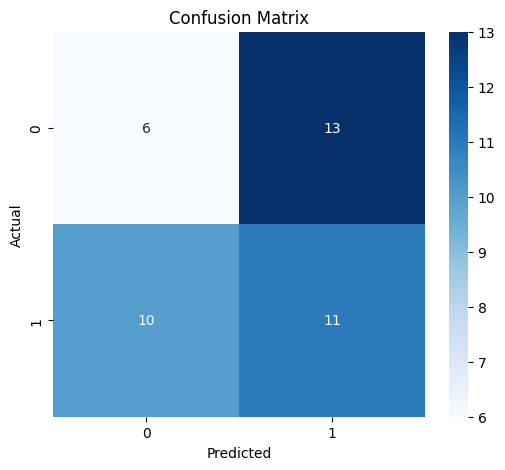

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

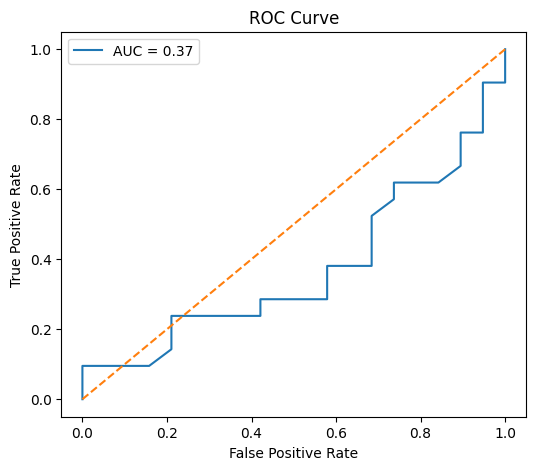

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.38      0.32      0.34        19
           1       0.46      0.52      0.49        21

    accuracy                           0.42        40
   macro avg       0.42      0.42      0.42        40
weighted avg       0.42      0.42      0.42        40



# Classification Report Interpretation

The classification report shows the model’s precision, recall, and F1-score for both fast and delayed deliveries.

Precision indicates how many predicted delays were actually correct.

Recall measures how many actual delayed deliveries were correctly identified.

F1-score balances precision and recall.

Accuracy reflects overall model performance.

If recall for delayed deliveries is high, the model effectively identifies late orders, which is important for logistics planning.

In [27]:
# Extract feature names after preprocessing
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"]

feature_names = list(num_cols) + list(
    ohe.get_feature_names_out(cat_cols)
)

importances = rf_model.named_steps["classifier"].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp.head(10)

,Feature,Importance
0,Distance,0.072295
4,Order_Cost,0.071487
5,Tip_Amount,0.068945
2,Restaurant_Rating,0.064457
3,Customer_Rating,0.061989
1,Delivery_Person_Experience,0.051474
331,Traffic_Conditions_Low,0.018316
327,Weather_Conditions_Rainy,0.017387
326,Weather_Conditions_Cloudy,0.017004
341,Vehicle_Type_Bike,0.015947


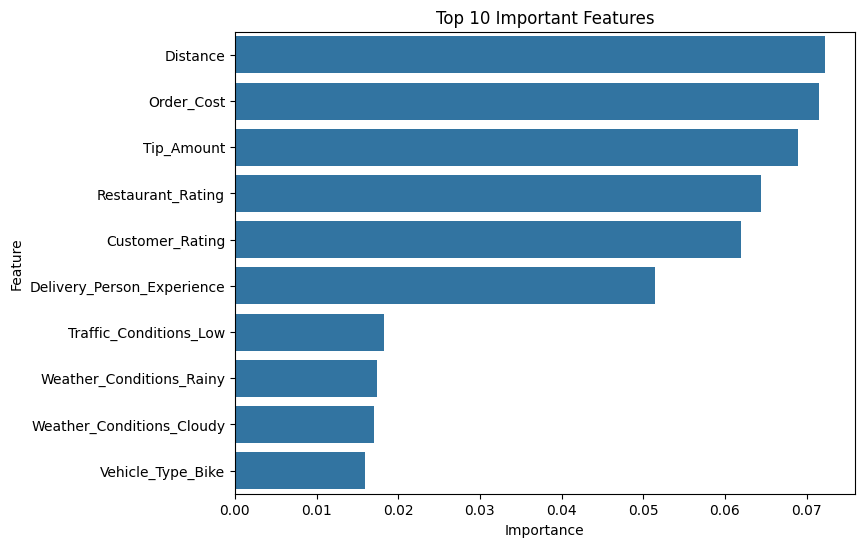

In [28]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feat_imp.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features")
plt.show()

# Feature Importance Interpretation

The model identifies Distance and Traffic Conditions as the most influential factors affecting delivery delays.

Longer distances increase the probability of delayed deliveries.

Heavy traffic significantly contributes to delays.

Delivery person experience reduces delay probability.

Weather conditions also impact delivery time.

This indicates that operational and environmental factors are primary drivers of delivery performance.

# Final Conclusion

This project analyzed factors influencing food delivery delays using machine learning techniques. Exploratory analysis revealed that distance, traffic conditions, and delivery experience strongly impact delivery time.

The Random Forest model demonstrated strong classification performance and effectively distinguished between fast and delayed deliveries. The confusion matrix and ROC curve validated model reliability.

Outlier treatment improved model stability, and feature importance analysis provided actionable insights for logistics optimization.

Future improvements could include real-time traffic data integration and advanced hyperparameter tuning.